The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

let's load our data

In [27]:
data = pd.read_csv('bank-full.csv', sep=';')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


On va commencer par vérifier la taille de notre dataset, les types de colonnes qui existent et les valeurs manquantes:

In [28]:
data.shape

(45211, 17)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [30]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [31]:
data.isna().sum()   

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

La taille de notre dataset : 17 colonnes pour 45211 entrée.

la colonne default est une information sur le risque de crédit du client:

    Oui: le client a déjà manqué un paiement de crédit.

    Non: le client n'a jamais manqué de paiement.

Duration : Durée du dernier contact (en secondes) fais avec le client, si jamais de contact alors la valeur est 0 et donc y=0(si le client n'est jamais contacté alors il ne peut pas souscrire). Nous on veut prédire si le client va souscrire avant l'appel, alors cette column va etre enlevée vu que la duration n'est connue qu'après le contact avec le client.


Vérifions le nombre de personne qui ont souscris ou non un dépôt à terme

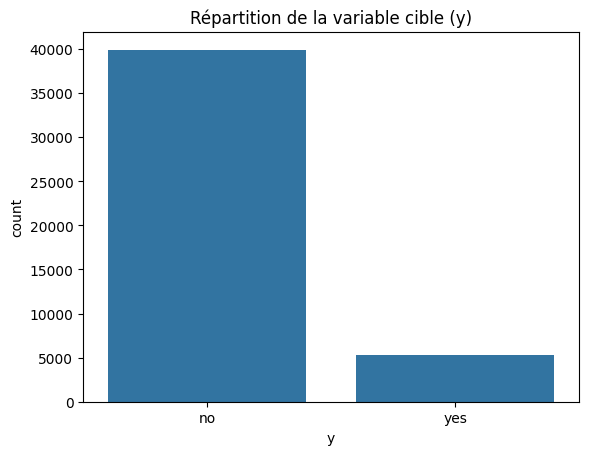

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [32]:
sns.countplot(x='y', data=data)
plt.title("Répartition de la variable cible (y)")
plt.show()

data['y'].value_counts(normalize=True) * 100


88.30% des clients n'ont pas sousrit 11.69% ont souscrit.

In [33]:
numeric_cols = ['age','balance','duration','campaign','pdays','previous']
categorical_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']


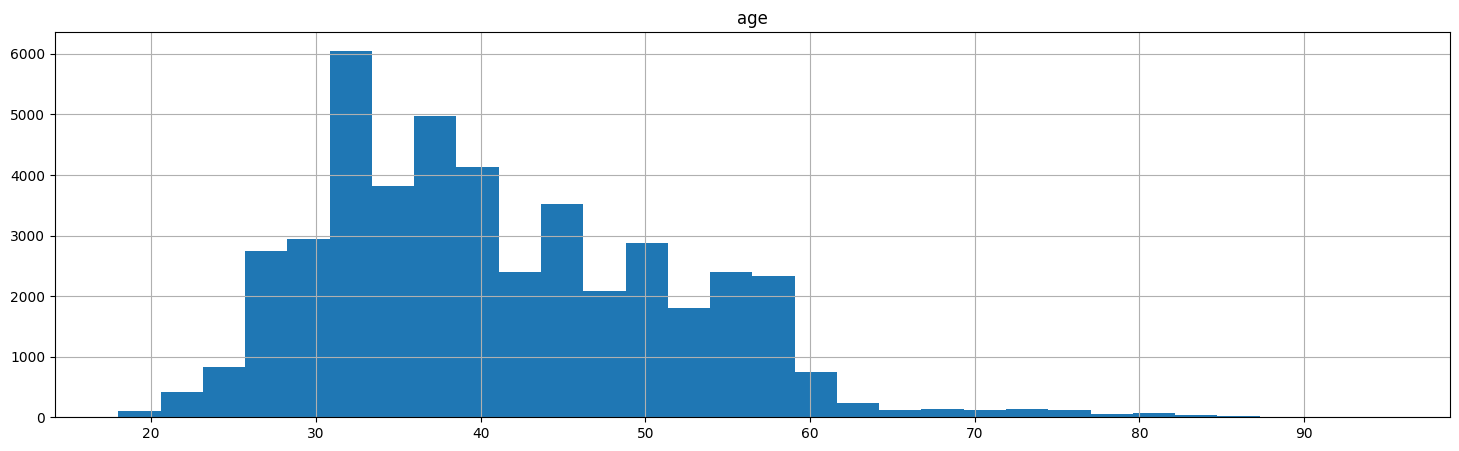

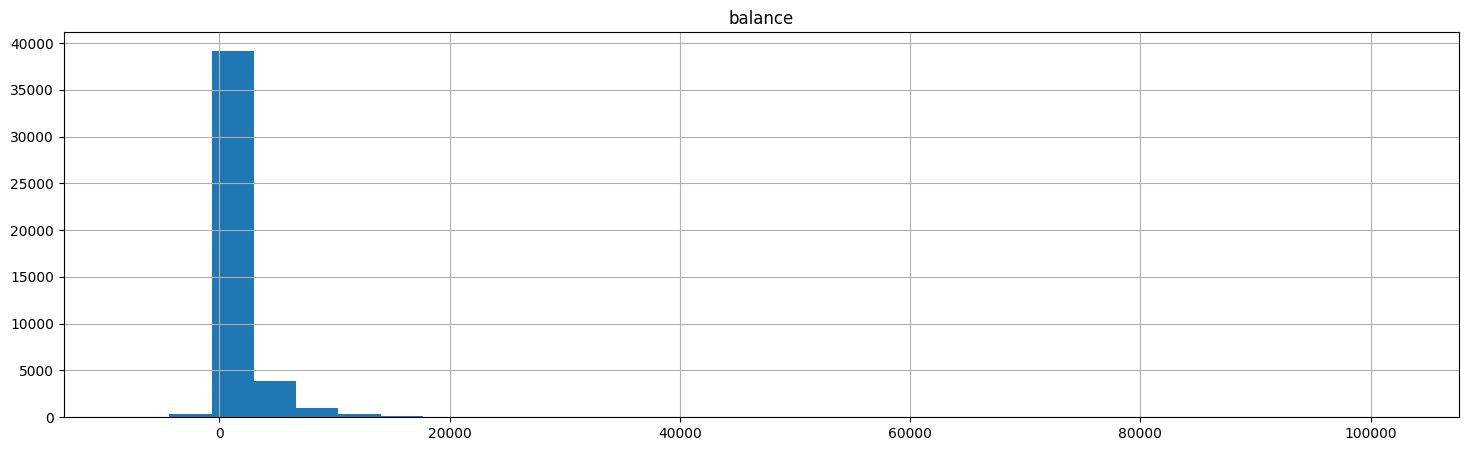

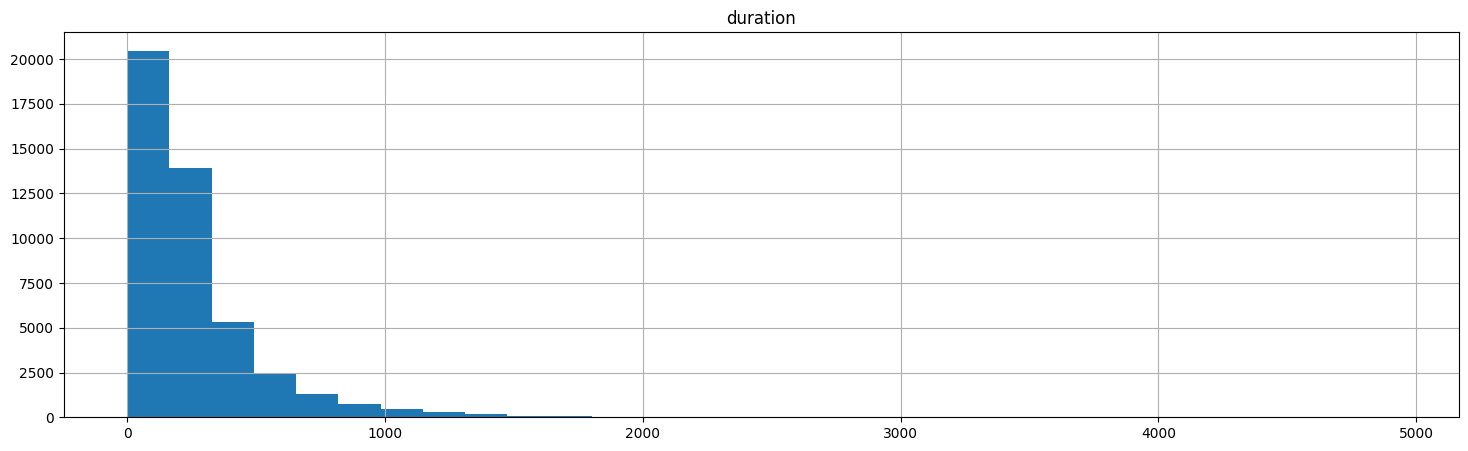

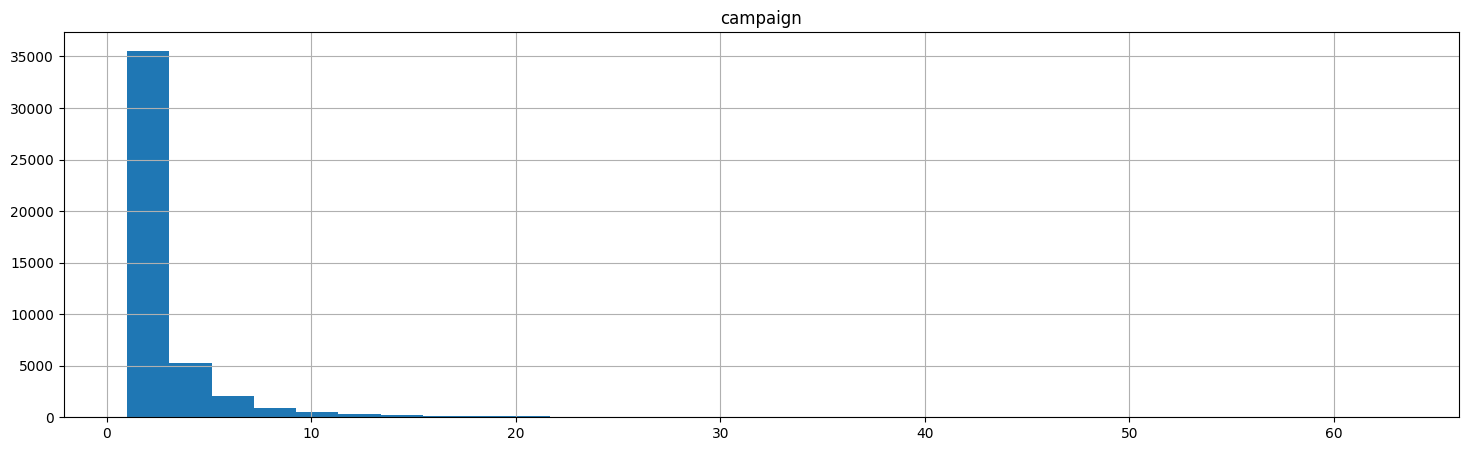

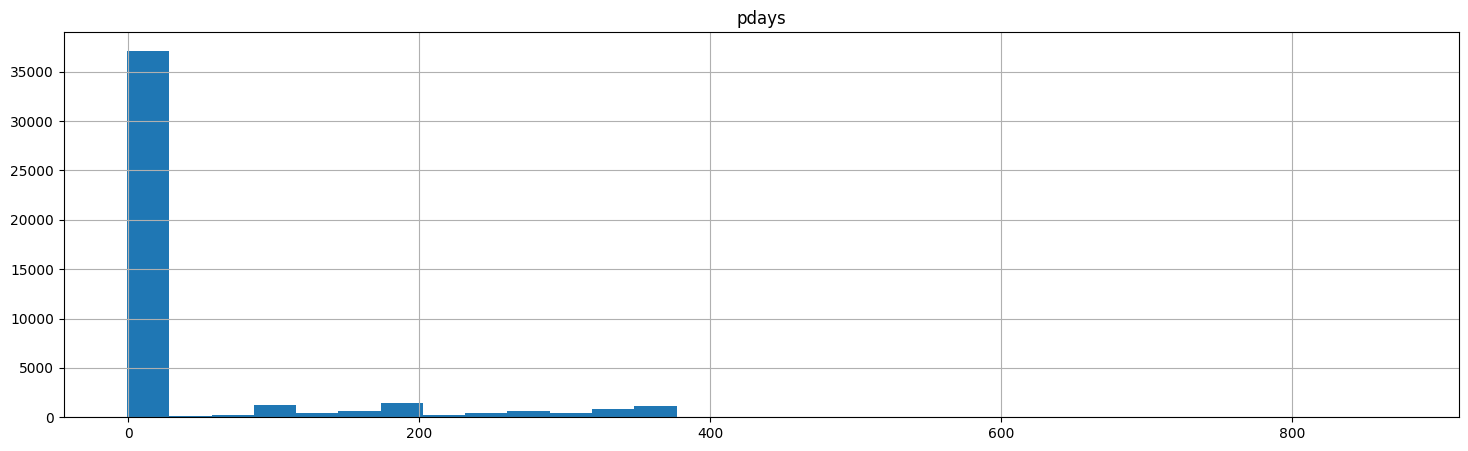

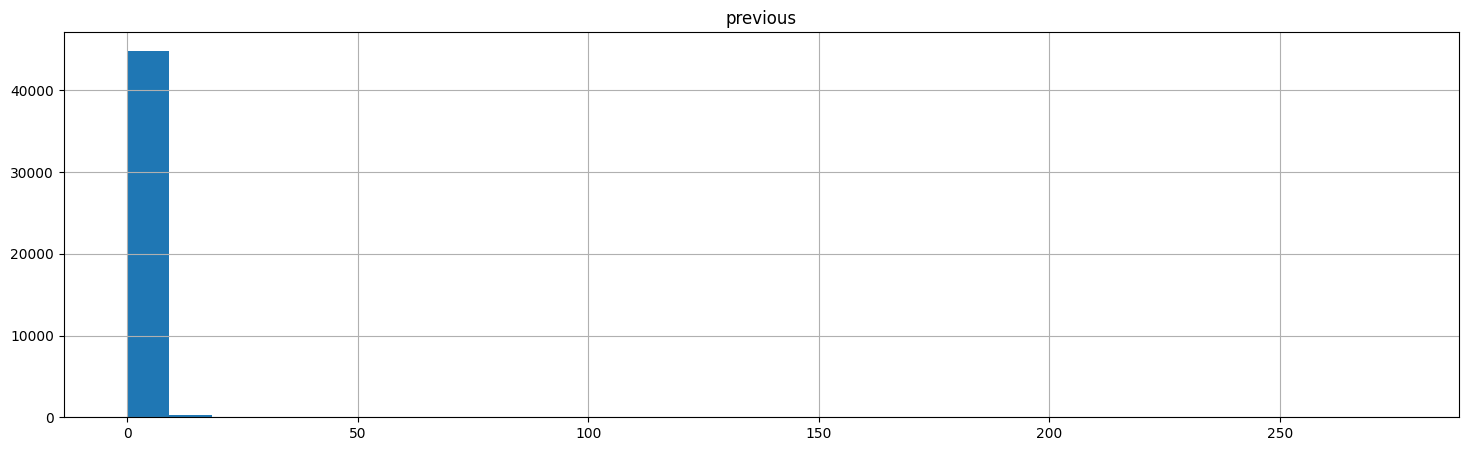

In [34]:
for i in numeric_cols:
    data[i].hist(figsize=(18,5), bins=30)
    plt.title(i)
    plt.show()

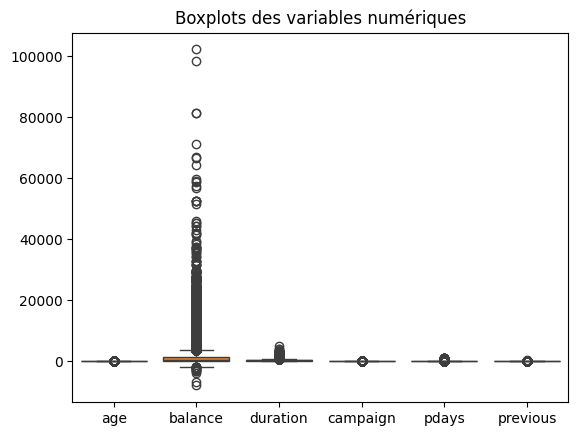

In [35]:
sns.boxplot(data=data[numeric_cols])
plt.title("Boxplots des variables numériques")
plt.show()

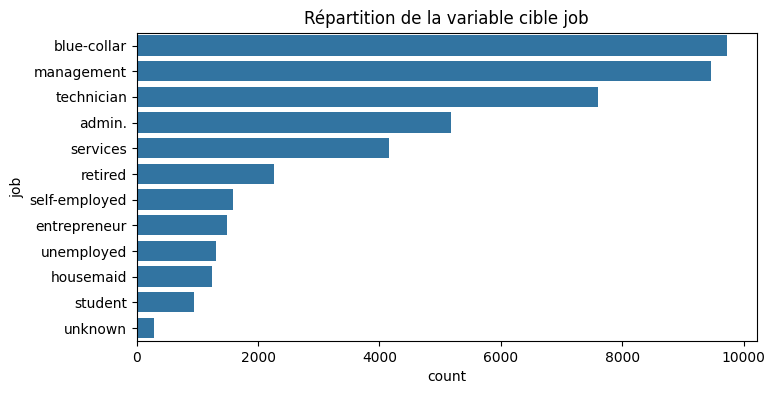

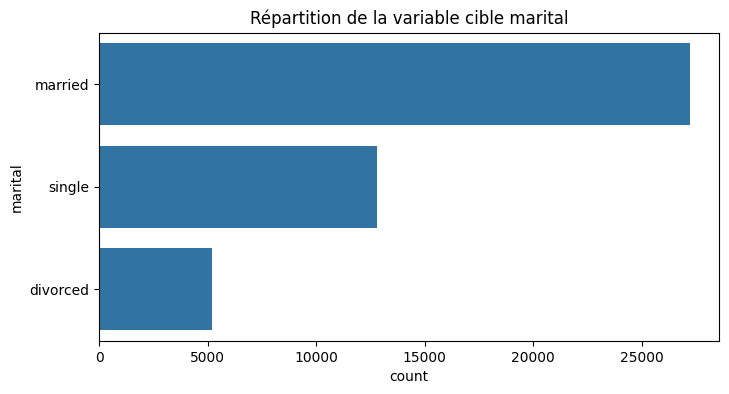

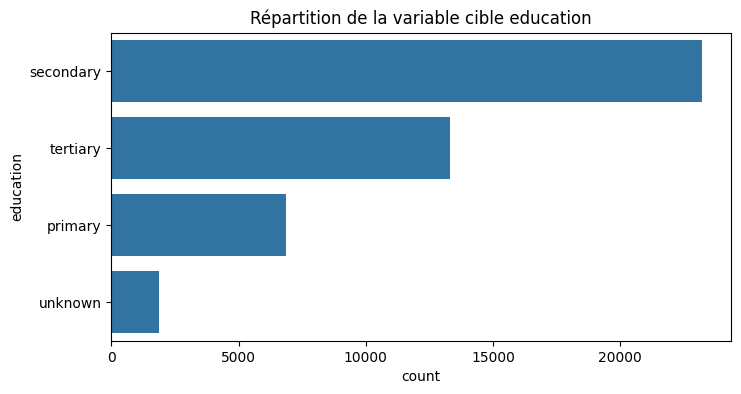

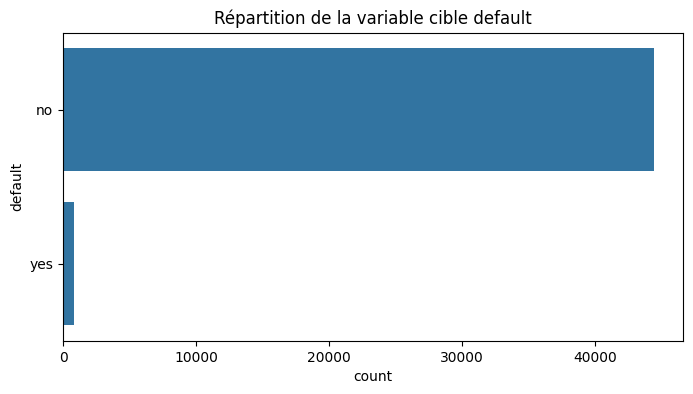

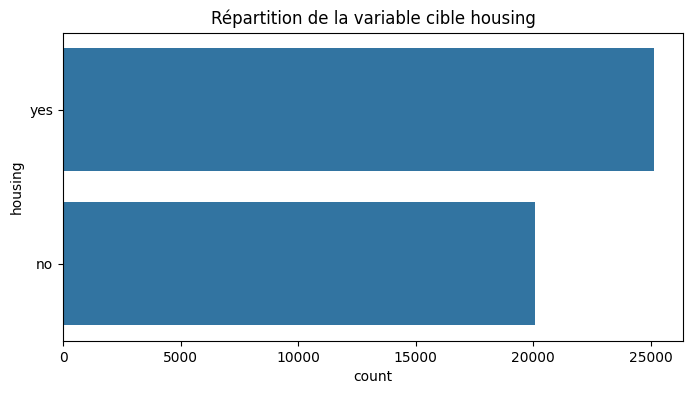

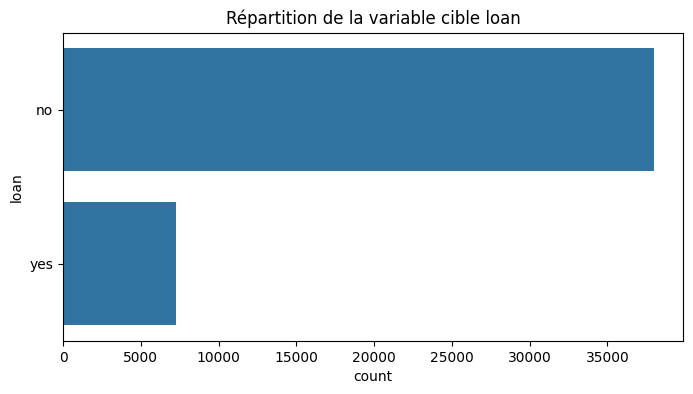

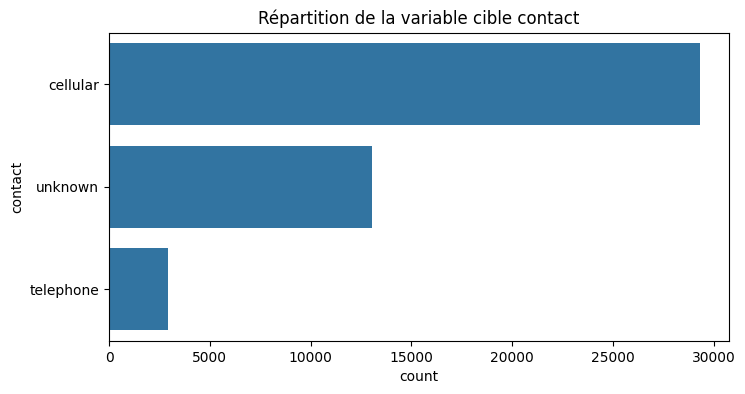

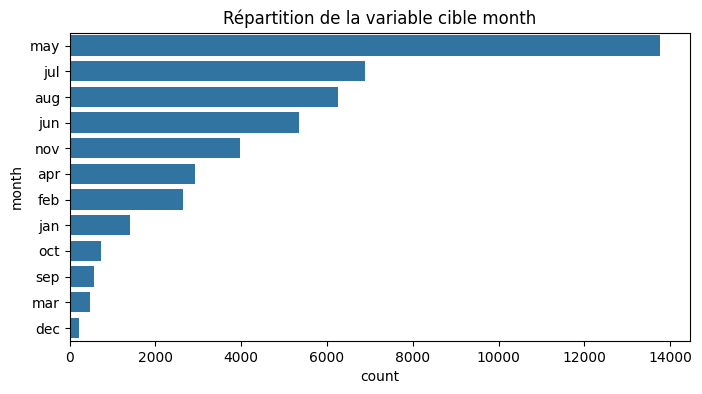

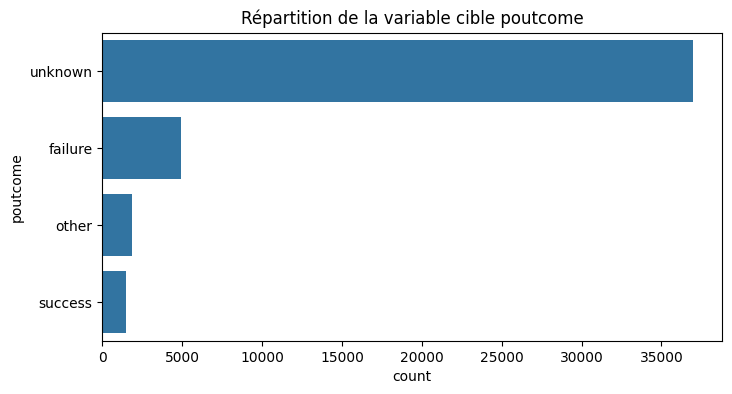

In [36]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(f"Répartition de la variable cible {col}")
    plt.show()

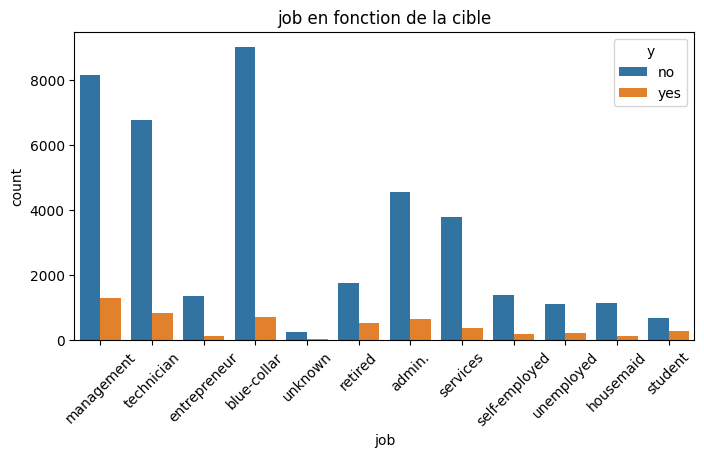

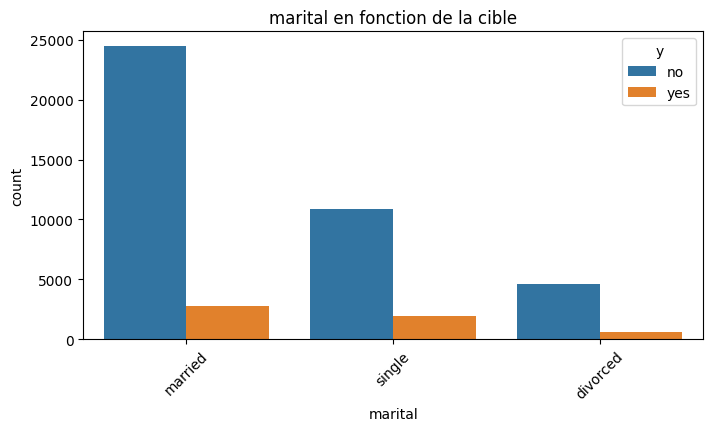

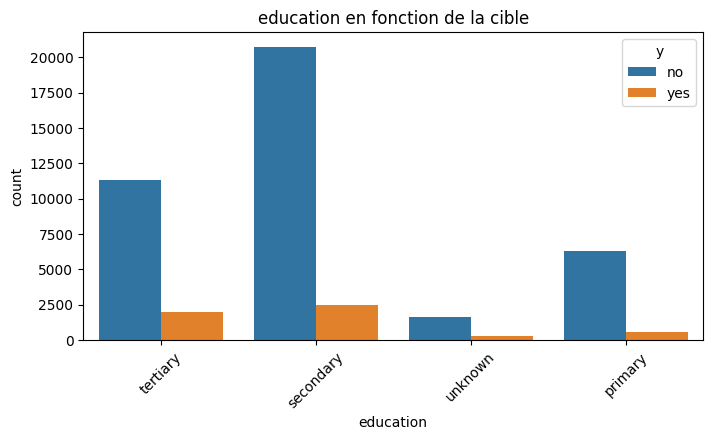

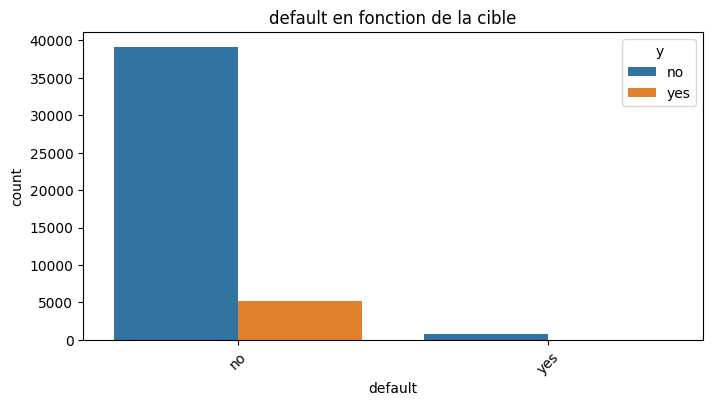

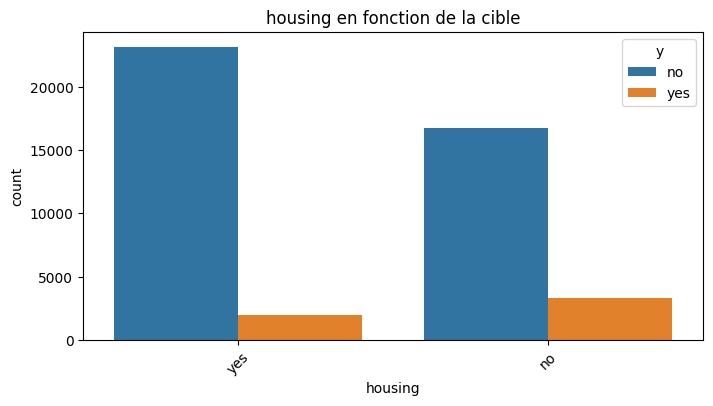

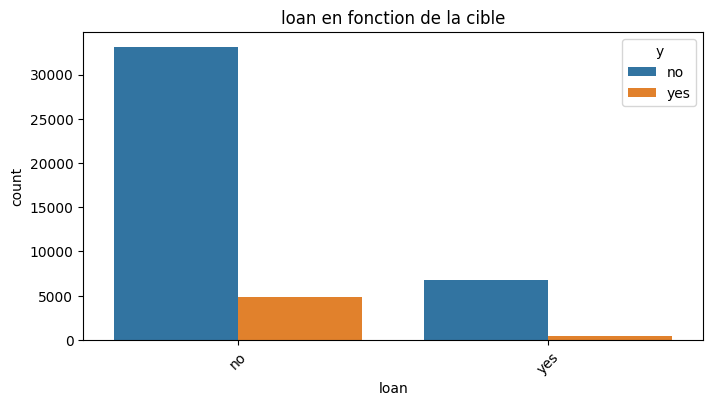

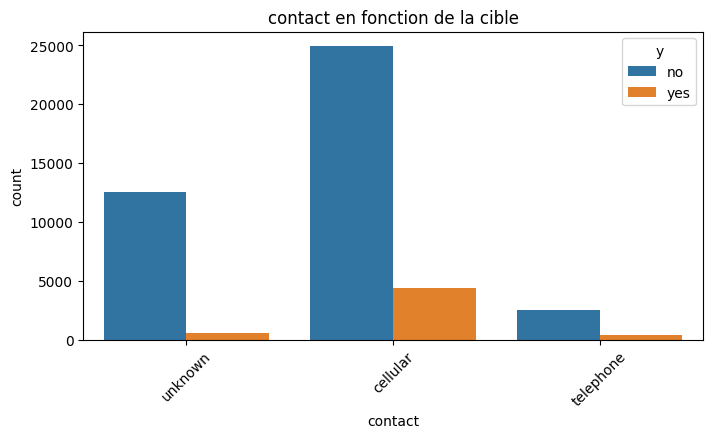

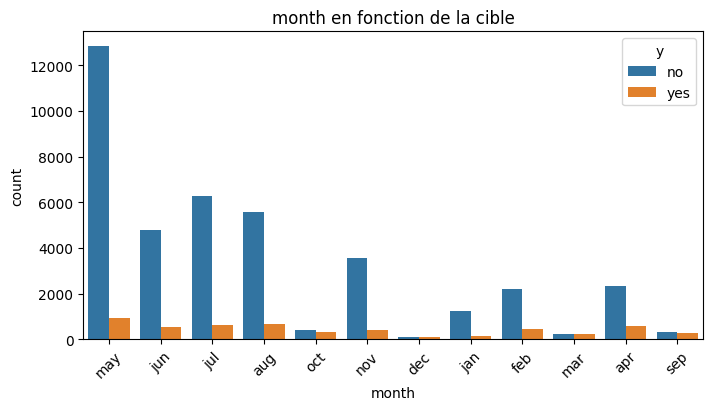

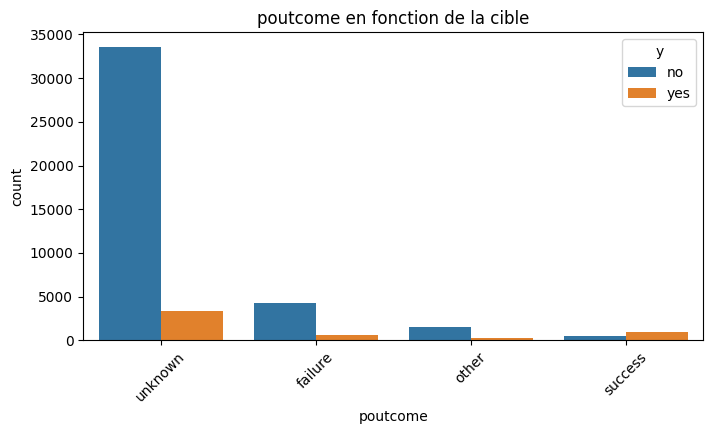

In [37]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='y', data=data)
    plt.title(f"{col} en fonction de la cible")
    plt.xticks(rotation=45)
    plt.show()

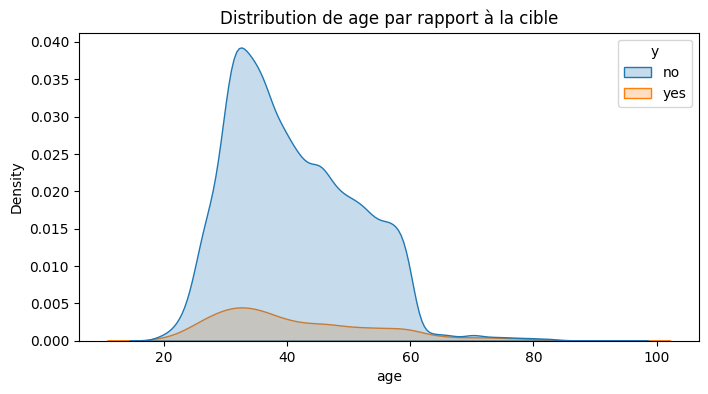

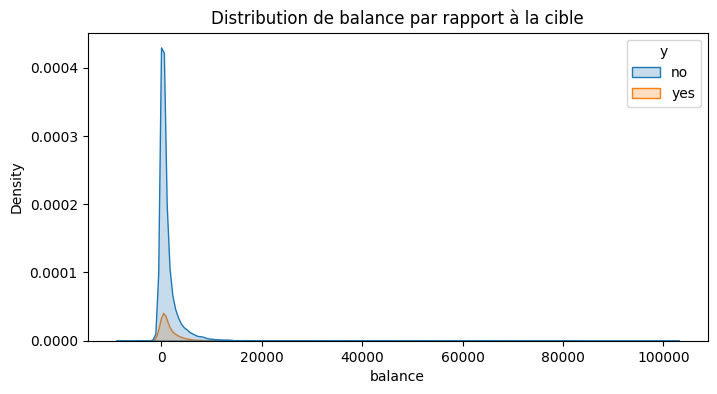

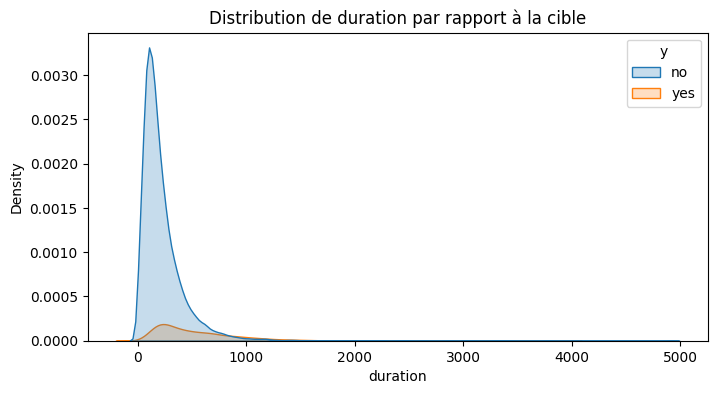

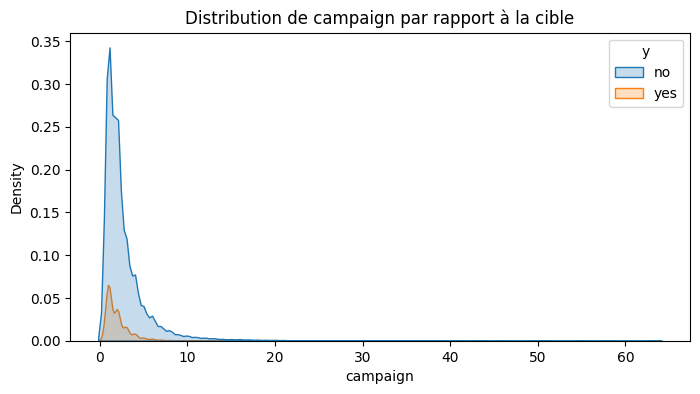

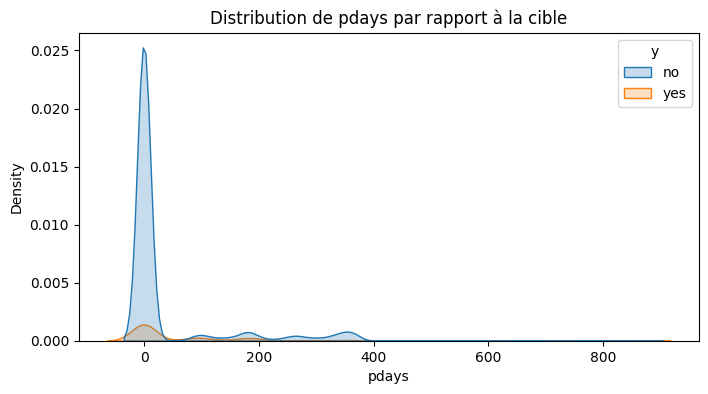

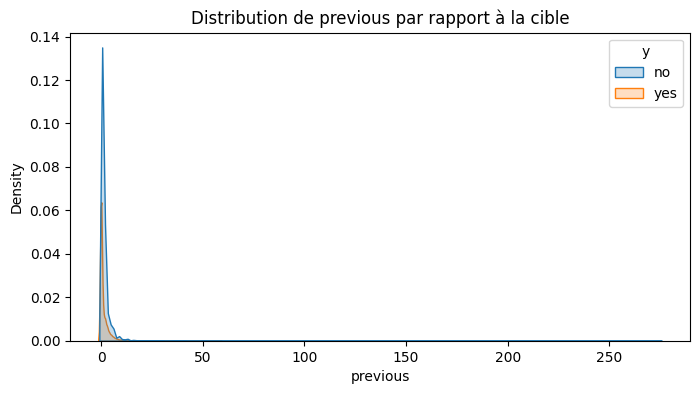

In [42]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=data, x=col, hue='y', fill=True)
    plt.title(f"Distribution de {col} par rapport à la cible")
    plt.show()

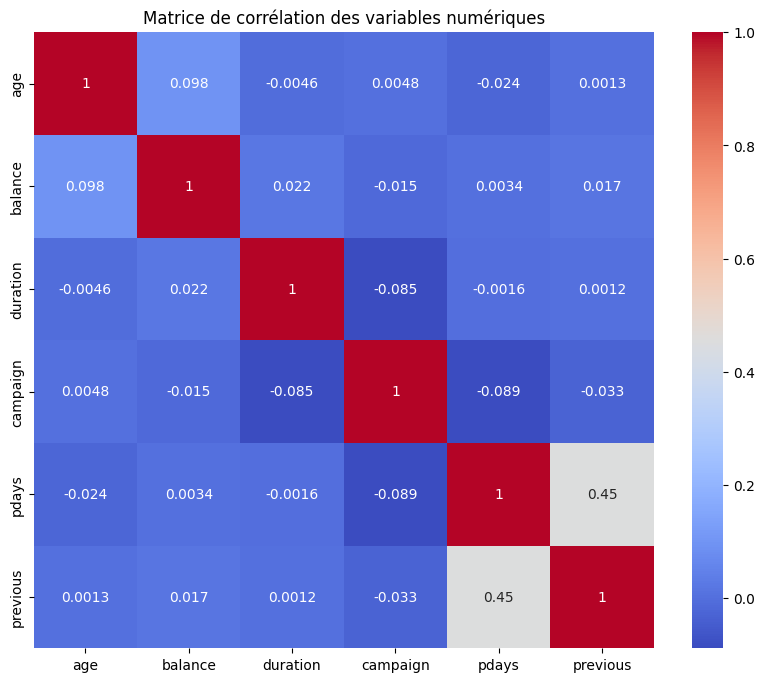

In [43]:
plt.figure(figsize=(10,8))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation des variables numériques")
plt.show()